In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("credit_dataset.csv")

In [12]:
FEATURES = [c for c in df.columns if c != "y_problem"]
X = df[FEATURES]
y = df["y_problem"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=100, random_state=42
)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1697
           1       0.88      0.84      0.86       303

    accuracy                           0.96      2000
   macro avg       0.93      0.91      0.92      2000
weighted avg       0.96      0.96      0.96      2000

ROC-AUC: 0.9915313570249188


In [16]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators":     [100, 200, 400, 600],
        "max_depth":        [None, 10, 15, 20],
        "min_samples_split":[2, 5, 10, 20],
    },
    cv=StratifiedKFold(5), scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)

best = grid.best_estimator_
print(grid.best_params_)
print("Best CV AUC:", grid.best_score_)

{'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 200}
Best CV AUC: 0.9910563663140983


In [10]:
from sklearn.metrics import roc_curve

y_prob = best.predict_proba(X_test)[:, 1]
fpr, tpr, thr = roc_curve(y_test, y_prob)
opt_thr = thr[np.argmax(tpr - fpr)]
print(f"Treshold: {opt_thr}")

y_pred = (y_prob >= opt_thr).astype(int)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Treshold: 0.19673467487264915
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      1697
           1       0.73      1.00      0.84       303

    accuracy                           0.94      2000
   macro avg       0.86      0.97      0.90      2000
weighted avg       0.96      0.94      0.95      2000

ROC-AUC: 0.9922207895509646


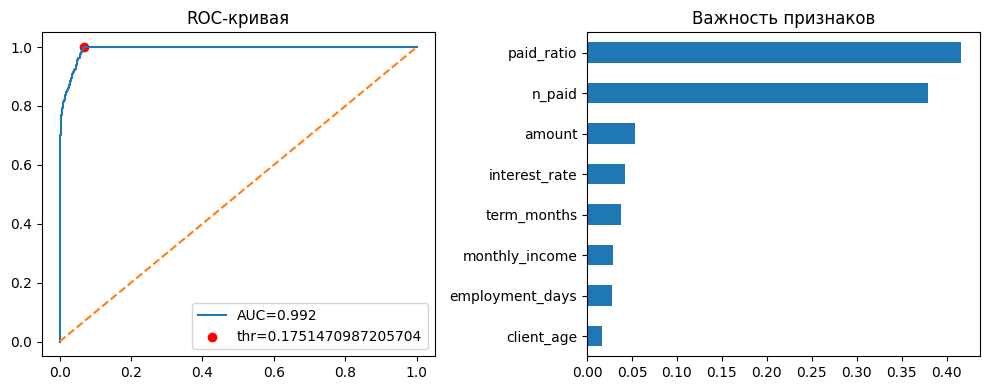

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(fpr, tpr, label=f"AUC={round(roc_auc_score(y_test, y_prob),3)}")
axes[0].plot([0,1],[0,1],"--")
axes[0].scatter(fpr[np.argmax(tpr-fpr)], tpr[np.argmax(tpr-fpr)], color="red", label=f"thr={opt_thr}")
axes[0].legend(); axes[0].set_title("ROC-кривая")

imp = pd.Series(best.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", ax=axes[1]); axes[1].set_title("Важность признаков")

plt.tight_layout();
plt.show()